<a href="https://colab.research.google.com/github/Flamers-Team/Techchalleng3/blob/main/notebooks/02_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏋️ Fine-Tuning de BioMistral-7B com MedQuAD

**Tech Challenge FIAP - Fase 3 | Assistente Médico Inteligente**

⚠️ **VERSÃO SEGURA**: Este notebook salva TUDO no Google Drive desde o início.
Se a sessão cair, basta reabrir e retomar com `resume_from_checkpoint=True`.

---

## 🎯 O que este notebook faz

Pega o modelo **BioMistral-7B** (já pré-treinado em PubMed) e ajusta ele especificamente com perguntas/respostas médicas do dataset **MedQuAD anonimizado**.

## ⏱️ Tempo estimado

- Setup: ~5 min
- Download modelo: ~10 min
- Treinamento: ~2-4h (2 epochs, A100)
- Salvar no Drive: ~1 min
- **TOTAL: ~3-5h** (pode deixar rodando sem supervisão após os primeiros 10 min)

## 🛡️ Segurança

- ✅ Tudo salvo em `/content/drive/MyDrive/techchallenge_fase3/`
- ✅ Checkpoints a cada epoch no Drive
- ✅ Retomável se cair (via `resume_from_checkpoint`)

---

# SEÇÃO 1: Setup do ambiente + Verificação GPU

**Antes de começar**:
1. Runtime → Change runtime type → Hardware: **A100 GPU**
2. Confirme que está rodando esta célula abaixo

In [29]:
# ============================================================
# SEÇÃO 1: Setup + Verificação GPU
# ============================================================
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print("=" * 60)
print(f"🖥️  GPU: {torch.cuda.get_device_name(0)}")
print(f"🖥️  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"🐍  Python: {torch.__version__}")
print("=" * 60)

if torch.cuda.get_device_properties(0).total_memory / 1e9 < 30:
    print("⚠️  AVISO: GPU tem menos de 30GB. Recomendado A100 (40GB).")
    print("   Se cair em OOM, reduza per_device_train_batch_size pra 1")
else:
    print("✅ GPU perfeita pra BioMistral-7B + QLoRA!")

Tue Sep  1 13:37:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             52W /  400W |    9448MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

**Esperado**:
```
🖥️  GPU: NVIDIA A100-SXM4-40GB
🖥️  VRAM: 40.0 GB
✅ GPU perfeita pra BioMistral-7B + QLoRA!
```

❌ Se aparecer GPU diferente ou erro: volte em **Runtime → Change runtime type**

---

# SEÇÃO 2: Instalar dependências

In [30]:
# ============================================================
# SEÇÃO 2: Instalar dependências (~2 min)
# ============================================================
# Usa subprocess em vez de !pip pra evitar problemas de parsing no Colab
import subprocess
import sys

print("📦 Instalando dependências... (2-3 min)")
print("   (vai aparecer muito output, é normal)")

# 1. PyTorch (versão mais recente compatível com o ambiente atual)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch",
    "--index-url", "https://download.pytorch.org/whl/cu124"
], check=True)
print("   ✅ torch instalado")

# 2. Pacotes HuggingFace (sem trava de versão para suportar Python 3.13)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers",
    "datasets",
    "peft",
    "bitsandbytes",
    "accelerate",
    "trl",
    "loguru",
], check=True)
print("   ✅ transformers, peft, bitsandbytes instalados")

# 3. Unsloth (instalação via git)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "unsloth[colab-new]",
    "git+https://github.com/unslothai/unsloth.git"
], check=True)
print("   ✅ unsloth instalado")

print("\n✅ Todas as dependências instaladas!")

📦 Instalando dependências... (2-3 min)
   (vai aparecer muito output, é normal)
   ✅ torch instalado
   ✅ transformers, peft, bitsandbytes instalados
   ✅ unsloth instalado

✅ Todas as dependências instaladas!


---

# SEÇÃO 3: Montar Google Drive (PERSISTÊNCIA)

⚠️ **MUITO IMPORTANTE**: vamos trabalhar **dentro do Drive** desde o início.
Isso garante que checkpoints e modelo final sobrevivam se a sessão cair.

In [31]:
# ============================================================
# SEÇÃO 3: Montar Drive + configurar paths persistentes
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Diretório de trabalho no Drive (PERSISTE mesmo se sessão cair)
WORKDIR = '/content/drive/MyDrive/techchallenge_fase3'
import os
os.makedirs(WORKDIR, exist_ok=True)
os.chdir(WORKDIR)

# Subdiretórios
CKPT_DIR = f"{WORKDIR}/checkpoints"          # checkpoints intermediários
MODEL_DIR = f"{WORKDIR}/biomistral-medquad-lora"  # modelo final
DATA_DIR = f"{WORKDIR}/data"                # onde vai o train.jsonl

for d in [CKPT_DIR, MODEL_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"✅ Working directory: {WORKDIR}")
print(f"   Checkpoints:  {CKPT_DIR}")
print(f"   Modelo final: {MODEL_DIR}")
print(f"   Dados:        {DATA_DIR}")
print()
print(f"📂 Conteúdo atual de {WORKDIR}:")
!ls -lh {WORKDIR}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working directory: /content/drive/MyDrive/techchallenge_fase3
   Checkpoints:  /content/drive/MyDrive/techchallenge_fase3/checkpoints
   Modelo final: /content/drive/MyDrive/techchallenge_fase3/biomistral-medquad-lora
   Dados:        /content/drive/MyDrive/techchallenge_fase3/data

📂 Conteúdo atual de /content/drive/MyDrive/techchallenge_fase3:
total 45K
drwx------ 2 root root 4.0K Aug 31 19:49 biomistral-medquad-lora
drwx------ 2 root root 4.0K Aug 31 19:49 checkpoints
drwx------ 2 root root 4.0K Aug 31 19:49 data
-rw------- 1 root root  19K Sep  1 12:59 eval_results_qualitativo.json
drwx------ 4 root root 4.0K Aug 31 19:52 huggingface_tokenizers_cache
-rw------- 1 root root 6.5K Sep  1 13:00 test_generalizacao.json
drwx------ 4 root root 4.0K Sep  1 12:53 unsloth_compiled_cache


## ⚠️ Agora faça upload do `train.jsonl` para o Drive

**Como fazer** (escolha uma):

### Opção A: Via PC → Drive (recomendado)
1. No seu PC, copie `C:\Users\Teste\Downloads\Techchalleng3\data\processed\train.jsonl` (17 MB)
2. Cole em `G:\Meu Drive\techchallenge_fase3\data\train.jsonl` (no seu Drive local)
3. Drive sincroniza automaticamente

### Opção B: Upload direto no Colab
```python
from google.colab import files
uploaded = files.upload()  # vai pedir pra selecionar arquivo
import shutil
shutil.move(list(uploaded.keys())[0], f"{DATA_DIR}/train.jsonl")
```

Depois de upar, **rode a célula abaixo** pra confirmar:

In [32]:
# ============================================================
# SEÇÃO 3.1: Verificar que train.jsonl está no Drive
# ============================================================
import os

train_path = f"{DATA_DIR}/train.jsonl"
if os.path.exists(train_path):
    size_mb = os.path.getsize(train_path) / 1024 / 1024
    with open(train_path) as f:
        n_lines = sum(1 for _ in f)
    print(f"✅ train.jsonl encontrado!")
    print(f"   Tamanho: {size_mb:.1f} MB")
    print(f"   Amostras: {n_lines:,}")
else:
    print(f"❌ train.jsonl NÃO encontrado em {train_path}")
    print(f"   Faça upload antes de continuar (veja célula acima)")
    raise FileNotFoundError("Upload train.jsonl primeiro!")

✅ train.jsonl encontrado!
   Tamanho: 17.1 MB
   Amostras: 14,692


---

# SEÇÃO 4: Carregar BioMistral-7B

Aqui é onde a mágica acontece. Vamos baixar o BioMistral-7B (~14GB) e configurar com QLoRA.

**O que é QLoRA**: Quantização do modelo base para 4-bit + adaptadores LoRA treináveis.
Em vez de ajustar os 7 bilhões de parâmetros, ajustamos apenas ~40 milhões (0.6% do total).

⏱️ **Esta célula leva ~5-10min na primeira vez** (download do modelo)

In [ ]:
# ============================================================
# SEÇÃO 4: Carregar BioMistral-7B com QLoRA
# ============================================================
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 4096  # tokens máximos por exemplo (instruction + input + output)
DTYPE = None           # auto-detectar (float16 ou bfloat16)
LOAD_IN_4BIT = True    # QLoRA: quantizar pra 4-bit (economiza 4x VRAM)

print("📥 Baixando BioMistral-7B... (pode levar 5-10 min na primeira vez)")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="BioMistral/BioMistral-7B",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
    # token="hf_XXXXXXXXXX",  # descomente se precisar autenticar no HuggingFace
)

print("\n✅ BioMistral-7B carregado!")
print(f"   Vocabulário: {tokenizer.vocab_size:,} tokens")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
📥 Baixando BioMistral-7B... (pode levar 5-10 min na primeira vez)
==((====))==  Unsloth 2026.8.22: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 77, in get_conversion_pr_reference
    raise OSError(
    ...<2 lines>...
    )
OSError: Could not create safetensors conversion PR. The repo does not appear t

Unsloth: BioMistral/BioMistral-7B has no pad_token. Using pad_token = <unk>.

✅ BioMistral-7B carregado!
   Vocabulário: 32,000 tokens


---

# SEÇÃO 5: Configurar LoRA adapters

Agora vamos adicionar os 'notas adesivas' (LoRA) ao modelo.

In [ ]:
# ============================================================
# SEÇÃO 5: Configurar LoRA adapters
# ============================================================
model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # rank LoRA (compromisso performance/velocidade)
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,  # fator de escala (= 2 * rank)
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = model.num_parameters()
pct = 100 * trainable_params / all_params

print("=" * 60)
print("📊 PARÂMETROS DO MODELO")
print("=" * 60)
print(f"  Total:           {all_params:,} ({all_params/1e9:.2f}B)")
print(f"  Treináveis:      {trainable_params:,} ({trainable_params/1e6:.1f}M)")
print(f"  % Treinável:     {pct:.4f}%")
print()
print("💡 Apenas ~0.6% dos parâmetros são treinados!")
print("   Por isso LoRA é tão rápido e leve.")

**Saída da Seção 5:**

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.8.22 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.

📊 PARÂMETROS DO MODELO

  Total:           7,283,675,136 (7.28B)
  Treináveis:      41,943,040 (41.9M)
  % Treinável:     0.5758%

💡 Apenas ~0.6% dos parâmetros são treinados!
   Por isso LoRA é tão rápido e leve.



---

# SEÇÃO 6: Carregar e formatar dataset

In [ ]:
# ============================================================
# SEÇÃO 6: Carregar dataset + template Alpaca
# ============================================================
from datasets import load_dataset

dataset = load_dataset("json", data_files=f"{DATA_DIR}/train.jsonl", split="train")
print(f"✅ Dataset carregado: {len(dataset):,} amostras")
print()
print(f"📝 Exemplo (amostra 0):")
print(f"   Instruction: {dataset[0]['instruction']}")
print(f"   Input:       {dataset[0]['input']}")
print(f"   Output:      {dataset[0]['output'][:200]}...")

Generating train split: 0 examples [00:00, ? examples/s]

✅ Dataset carregado: 14,692 amostras

📝 Exemplo (amostra 0):
   Instruction: Is Russell-Silver syndrome inherited ?
   Input:       Context / Topic: Russell-Silver syndrome
   Output:      Most cases of Russell-Silver syndrome are sporadic, which means they occur in people with no history of the disorder in their family. Less commonly, Russell-Silver syndrome can run in families. In som...


In [ ]:
# ============================================================
# SEÇÃO 6.1: Aplicar template Alpaca
# ============================================================
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token


def format_example(example):
    """Formata 1 exemplo no template Alpaca."""
    text = alpaca_prompt.format(
        example["instruction"],
        example.get("input", ""),
        example["output"]
    ) + EOS_TOKEN
    return {"text": text}


dataset = dataset.map(format_example)

print("=" * 60)
print("✅ Dataset formatado no template Alpaca")
print("=" * 60)
print()
print(f"📝 Exemplo formatado (amostra 0):\n")
print(dataset[0]["text"][:600])
print("...")

Map:   0%|          | 0/14692 [00:00<?, ? examples/s]

✅ Dataset formatado no template Alpaca

📝 Exemplo formatado (amostra 0):

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Is Russell-Silver syndrome inherited ?

### Input:
Context / Topic: Russell-Silver syndrome

### Response:
Most cases of Russell-Silver syndrome are sporadic, which means they occur in people with no history of the disorder in their family. Less commonly, Russell-Silver syndrome can run in families. In some affected families, the condition appears to have an autosomal dominant pattern of inheritance. Autosomal dominant i
...


---

# SEÇÃO 7: Configurar o Trainer

In [ ]:
# ============================================================
# SEÇÃO 7: Configurar SFTTrainer
# ============================================================
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,         # batch efetivo = 8
        warmup_steps=50,
        num_train_epochs=2,                   # 2 epochs é o sweet spot
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=20,                      # log a cada 20 steps
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=42,
        output_dir=CKPT_DIR,                   # ← SALVA NO DRIVE!
        save_strategy="epoch",                # salva após cada epoch
        save_total_limit=2,                   # mantém 2 últimos
        report_to="none",                     # sem wandb
    ),
)

print("✅ Trainer configurado!")
print(f"   Dataset:      {len(dataset):,} amostras")
print(f"   Batch efetivo: 2 × 4 = 8")
print(f"   Steps/epoch:  {len(dataset)//8:,}")
print(f"   Total steps:  {len(dataset)//8*2:,} (2 epochs)")
print(f"   Checkpoints:  {CKPT_DIR}")
print(f"   Tempo estimado A100: 2-4h")

**Saída da Seção 7**:

Unsloth: Tokenizing ["text"] (num_proc=6): 100%
 14692/14692 [00:02<00:00, 8357.71 examples/s]

✅ Trainer configurado!
   Dataset:      14,692 amostras
   Batch efetivo: 2 × 4 = 8
   Steps/epoch:  1,836
   Total steps:  3,672 (2 epochs)
   Checkpoints:  /content/drive/MyDrive/techchallenge_fase3/checkpoints
   Tempo estimado A100: 2-4h


---

# SEÇÃO 8: 🚀 TREINAR! (essa é a parte demorada)

Agora vamos **rodar o fine-tuning**. A célula abaixo pode levar 2-4h.

**Dicas:**
- ✅ Pode **minimizar** a janela — o treino continua
- ✅ Pode **fechar** o navegador — o treino continua!
- ✅ Verá mensagens de progresso a cada 20 steps
- ✅ Se cair, basta reabrir e usar `resume_from_checkpoint=True`

**⚠️ Importante**: Se você quer **retomar de onde parou** (caso tenha caído antes), mude a última linha para:
```python
trainer.train(resume_from_checkpoint=True)
```

In [ ]:
# ============================================================
# SEÇÃO 8: TREINAMENTO 🚀
# ============================================================
print("=" * 60)
print("🚀 INICIANDO TREINAMENTO")
print("=" * 60)
print("⏱️  Tempo estimado: 2-4 horas em A100")
print(f"💾 Checkpoints salvos em: {CKPT_DIR}")
print("💡 Pode fechar o navegador — o treino continua!")
print()

# ⚠️ Se você REINICIOU após queda, descomente a linha abaixo:
# trainer.train(resume_from_checkpoint=True)

trainer.train()

print()
print("=" * 60)
print("✅ TREINAMENTO CONCLUÍDO!")
print("=" * 60)

**Saída da seção 8**:

🚀 INICIANDO TREINAMENTO

⏱️  Tempo estimado: 2-4 horas em A100
💾 Checkpoints salvos em: /content/drive/MyDrive/techchallenge_fase3/checkpoints
💡 Pode fechar o navegador — o treino continua!

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 14,692 | Num Epochs = 2 | Total steps = 3,674
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,283,675,136 (0.58% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.

[3674/3674 2:18:05, Epoch 2/2]
Step 	Training Loss
20 	1.425015
40 	0.910815
60 	0.872208
80 	0.836784
100 	0.802327
120 	0.766477
140 	0.820915
160 	0.790022
180 	0.782128
200 	0.799095
220 	0.766360
240 	0.770605
260 	0.710993
280 	0.776335
300 	0.682909
320 	0.766794
340 	0.752965
360 	0.778859
380 	0.789178
400 	0.740196
420 	0.746872
440 	0.758348
460 	0.767517
480 	0.737387
500 	0.666623
520 	0.729053
540 	0.734138
560 	0.739303
580 	0.771169
600 	0.731314
620 	0.742491
640 	0.754853
660 	0.714523
680 	0.746575
700 	0.750978
720 	0.708208
740 	0.762832
760 	0.673548
780 	0.750803
800 	0.700468
820 	0.687337
840 	0.750080
860 	0.717627
880 	0.715287
900 	0.750960
920 	0.763742
940 	0.687063
960 	0.749196
980 	0.682367
1000 	0.686075
1020 	0.726342
1040 	0.719475
1060 	0.819817
1080 	0.761964
1100 	0.688301
1120 	0.631912
1140 	0.701239
1160 	0.727347
1180 	0.663750
1200 	0.693236
1220 	0.702968
1240 	0.696678
1260 	0.654970
1280 	0.721226
1300 	0.715152
1320 	0.698309
1340 	0.693118
1360 	0.725488
1380 	0.657390
1400 	0.767714
1420 	0.727760
1440 	0.667467
1460 	0.663843
1480 	0.661992
1500 	0.674924
1520 	0.677854
1540 	0.711606
1560 	0.711000
1580 	0.707258
1600 	0.697049
1620 	0.694921
1640 	0.717181
1660 	0.669319
1680 	0.693333
1700 	0.696291
1720 	0.718297
1740 	0.613263
1760 	0.713931
1780 	0.665552
1800 	0.685021
1820 	0.700543
1840 	0.645472
1860 	0.533460
1880 	0.492297
1900 	0.484157
1920 	0.495517
1940 	0.498136
1960 	0.521814
1980 	0.497355
2000 	0.430841
2020 	0.439425
2040 	0.464061
2060 	0.465067
2080 	0.499513
2100 	0.463024
2120 	0.503436
2140 	0.482862
2160 	0.512533
2180 	0.475393
2200 	0.486357
2220 	0.458672
2240 	0.499444
2260 	0.459282
2280 	0.459584
2300 	0.476216
2320 	0.498962
2340 	0.493584
2360 	0.473498
2380 	0.486715
2400 	0.454081
2420 	0.490848
2440 	0.508711
2460 	0.451088
2480 	0.515961
2500 	0.459500
2520 	0.488421
2540 	0.474952
2560 	0.467527
2580 	0.437772
2600 	0.494091
2620 	0.462760
2640 	0.478247
2660 	0.493617
2680 	0.447338
2700 	0.442742
2720 	0.504775
2740 	0.415566
2760 	0.482033
2780 	0.472554
2800 	0.471077
2820 	0.483994
2840 	0.451529
2860 	0.436261
2880 	0.494207
2900 	0.434225
2920 	0.439365
2940 	0.518660
2960 	0.455412
2980 	0.497127
3000 	0.459296
3020 	0.492876
3040 	0.429821
3060 	0.474764
3080 	0.514395
3100 	0.435159
3120 	0.450216
3140 	0.431767
3160 	0.470215
3180 	0.450187
3200 	0.438217
3220 	0.434687
3240 	0.486812
3260 	0.438461
3280 	0.452950
3300 	0.479031
3320 	0.433947
3340 	0.460248
3360 	0.445312
3380 	0.440931
3400 	0.478121
3420 	0.479655
3440 	0.450820
3460 	0.449467
3480 	0.454273
3500 	0.432071
3520 	0.471308
3540 	0.465208
3560 	0.444569
3580 	0.429519
3600 	0.415150
3620 	0.407133
3640 	0.467596
3660 	0.452822

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/techchallenge_fase3/checkpoints/checkpoint-1837/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/techchallenge_fase3/checkpoints/checkpoint-1837.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/techchallenge_fase3/checkpoints/checkpoint-3674/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/techchallenge_fase3/checkpoints/checkpoint-3674.

✅ TREINAMENTO CONCLUÍDO!


---

# SEÇÃO 9: Salvar modelo final no Drive

Após o treino, salvamos os adaptadores LoRA (são só ~80MB) no Drive.

In [ ]:
# ============================================================
# SEÇÃO 9: Salvar modelo final no Drive
# ============================================================
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("=" * 60)
print("💾 MODELO SALVO!")
print("=" * 60)
print(f"📂 Diretório: {MODEL_DIR}")
print()
!ls -lh {MODEL_DIR}/

import os
size_mb = sum(
    os.path.getsize(os.path.join(MODEL_DIR, f))
    for f in os.listdir(MODEL_DIR)
) / 1024 / 1024

print(f"\n📦 Tamanho total: {size_mb:.1f} MB")
print("   (Bem menor que o modelo completo de 14GB!)")

**Saída da Seção 9**:

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/techchallenge_fase3/biomistral-medquad-lora/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/techchallenge_fase3/biomistral-medquad-lora.


💾 MODELO SALVO!

📂 Diretório: /content/drive/MyDrive/techchallenge_fase3/biomistral-medquad-lora

total 164M
-rw------- 1 root root 1.3K Aug 31 22:20 adapter_config.json
-rw------- 1 root root 161M Aug 31 22:20 adapter_model.safetensors
-rw------- 1 root root  477 Aug 31 22:20 chat_template.jinja
-rw------- 1 root root 5.2K Aug 31 22:20 README.md
-rw------- 1 root root  965 Aug 31 22:20 tokenizer_config.json
-rw------- 1 root root 3.4M Aug 31 22:20 tokenizer.json
-rw------- 1 root root 482K Aug 31 19:51 tokenizer.model

📦 Tamanho total: 163.9 MB
   (Bem menor que o modelo completo de 14GB!)



---

# SEÇÃO 10: Testar o modelo com perguntas reais

In [ ]:
# ============================================================
# SEÇÃO 10: Inferência — testar o modelo
# ============================================================
from transformers import TextStreamer

# Ativar modo inferência do Unsloth (mais rápido)
FastLanguageModel.for_inference(model)

def perguntar(instruction: str, topic: str = ""):
    """Faz uma pergunta ao modelo fine-tuned."""
    input_text = alpaca_prompt.format(
        instruction,
        f"Context / Topic: {topic}" if topic else "",
        ""
    )

    inputs = tokenizer([input_text], return_tensors="pt").to("cuda")
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

    print(f"\n{'='*70}")
    print(f"❓ PERGUNTA: {instruction}")
    if topic:
        print(f"📋 TÓPICO: {topic}")
    print(f"{'='*70}")
    print(f"🤖 RESPOSTA:")

    _ = model.generate(
        **inputs,
        streamer=streamer,
        max_new_tokens=512,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.2,
    )
    print()

# Testar com 3 perguntas
perguntar(
    "What are the symptoms of diabetes type 2?",
    "Diabetes Type 2"
)

perguntar(
    "What are the treatments for high blood pressure?",
    "Hypertension"
)

perguntar(
    "Is breast cancer hereditary?",
    "Breast Cancer"
)

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



❓ PERGUNTA: What are the symptoms of diabetes type 2?
📋 TÓPICO: Diabetes Type 2

🤖 RESPOSTA:
People with diabetes have high blood glucose (sugar) levels because their bodies do not make enough insulin or cannot use insulin effectively. Symptoms may include excessive thirst and urination; increased appetite; weight loss; fatigue; blurred vision; slow healing of wounds; sores in mouth; and dry, itchy skin. People who develop complications from diabetes can also experience numbness or tingling sensations in the feet; headaches; heart problems; kidney disease; eye damage; dental disease; hearing loss; leg amputation; depression; and erectile dysfunction.



❓ PERGUNTA: What are the treatments for high blood pressure?
📋 TÓPICO: Hypertension

🤖 RESPOSTA:

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

Medications and lifestyle changes can effectively control most cases of hypertension. Medications Angiotensin-Converting Enzyme (ACE) Inhibitors ACE inhibitors block angiotensin II from being produced in the body. This reduces narrowing or tightening of blood vessels and lowers blood pressure. The medications used to treat this condition include lisinopril (Princepleen), ramipril (Haltelite), enalapril (Aggrastat), captopril, and trandolapril (Meridia). All of these drugs also act as diuretics. Captopril acts primarily on the kidneys to reduce fluid levels; however it may cause dry coughs in some people. Benazepril (Lozolam) is another medication that works like other ACE inhibitors but has been shown to be effective even at very low dosages. Diuretics Diuretics help your body get rid of extra sodium (salt) and water. Water stays in the body because it carries needed nutrients to all parts of the body. However, too much water causes higher blood pressure. Taking diuretics makes you urinate more often so excess water leaves your body. There are different types of diuretics depending on which part of your kidney they affect. Hydrochlorothiazide (EssiQte), chlorthalidone (Theraid), and hydroflut azine (Microzol) are taken by mouth once daily. They work best when taken early in the morning before eating breakfast. Potassium-sparing diuretics amiloride (Meglitol) and trimethoprim/sulfamethoxazole (Bactrim) do not remove salt from the body as efficiently as other diuretics. Instead, they lower blood pressure by reducing potassium levels in your body. Amiloride should not be taken with any other diuretics because doing so could lead to serious side effects such as muscle weakness. Other BP Medicines If you have diabetes or if two or more medicines alone cannot control your blood pressure, then your doctor may prescribe a third medicine. Often a beta blocker is combined with an ACE inhibitor. Sometimes a calcium channel blocker is added. Beta Blockers Beta blockers slow down activity of your heart's sympathetic



❓ PERGUNTA: Is breast cancer hereditary?
📋 TÓPICO: Breast Cancer

🤖 RESPOSTA:

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

Breast cancer can be caused by inherited gene mutations (changes), but most cases are not inherited. Changes in several genes have been associated with increased risk of breast cancer; however, only high-risk gene changes account for a significant percentage of all breast cancer cases. The rest of the time, people who develop this disease do not have an identified gene change known to increase their chances of developing it.



---

# SEÇÃO 11: Avaliação quantitativa (perplexity no val set)

In [ ]:
import math
from datasets import load_dataset
import os

# Carregar val.jsonl do Drive (deve estar lá se você upou train.jsonl completo)
VAL_FILE = f"{DATA_DIR}/val.jsonl"

if not os.path.exists(VAL_FILE):
    print(f"⚠️  val.jsonl não encontrado em {VAL_FILE}")
    print(f"   Se você só upou train.jsonl, copie val.jsonl também do seu PC.")
    print(f"   Val.jsonl está em: C:\\Users\\Teste\\Downloads\\Techchalleng3\\data\\processed\\val.jsonl")
else:
    # Correção: O split padrão para um único arquivo JSONL é 'train'
    val_dataset = load_dataset("json", data_files=VAL_FILE, split="train")
    print(f"📂 Carregado val set: {len(val_dataset):,} amostras\n")

    total_loss = 0
    n_samples = 0
    MAX_EVAL_SAMPLES = 100

    model.eval()
    with torch.no_grad():
        for i, example in enumerate(val_dataset):
            if i >= MAX_EVAL_SAMPLES:
                break

            text = alpaca_prompt.format(
                example["instruction"],
                example.get("input", ""),
                example["output"]
            )
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to("cuda")

            outputs = model(**inputs, labels=inputs["input_ids"])
            total_loss += outputs.loss.item()
            n_samples += 1

            if (i + 1) % 20 == 0:
                print(f"   Avaliado {i+1}/{MAX_EVAL_SAMPLES} amostras...")

    perplexity = math.exp(total_loss / n_samples)

    print()
    print("=" * 60)
    print("📊 RESULTADO DA AVALIAÇÃO")
    print("=" * 60)
    print(f"  Loss média:    {total_loss / n_samples:.4f}")
    print(f"  Perplexity:    {perplexity:.2f}")
    print()
    print("💡 Interpretação:")
    print("   • < 5   = Modelo 'decorou' o val set")
    print("   • 5-15 = Excelente (aprendeu o domínio)")
    print("   • 15-30 = Bom")
    print("   • > 50 = Modelo ainda não aprendeu")

`use_return_dict` is deprecated! Use `return_dict` instead!


📂 Carregado val set: 816 amostras

   Avaliado 20/100 amostras...
   Avaliado 40/100 amostras...
   Avaliado 60/100 amostras...
   Avaliado 80/100 amostras...
   Avaliado 100/100 amostras...

📊 RESULTADO DA AVALIAÇÃO
  Loss média:    1.9728
  Perplexity:    7.19

💡 Interpretação:
   • < 5   = Modelo 'decorou' o val set
   • 5-15 = Excelente (aprendeu o domínio)
   • 15-30 = Bom
   • > 50 = Modelo ainda não aprendeu


---

# SEÇÃO 11.1 --- Peça 1: Curva de loss de treino

**O que é e por que importa (para iniciantes):**

Durante o treino, a cada 20 passos (`logging_steps=20`) o `Trainer` anotou a *training
loss*: um número que mede o quanto o modelo erra **nos exemplos que ele está estudando
naquele momento**. Menor = ele acertou melhor aquele lote.

Sozinha, a curva de treino **não prova** overfitting, mas mostra dois sinais:

1. **A loss caiu e depois estabilizou num patamar?** Isso é saudável --- o modelo
   aprendeu e parou de melhorar.
2. **Aparece um "degrau" para baixo bem no começo da 2ª época?** Atenção. Se a loss dá
   um salto para baixo exatamente quando o modelo começa a ver os exemplos pela
   **segunda vez**, é porque ele está *reconhecendo* exemplos já vistos --- ou seja,
   começando a **decorar** (primeiro indício de overfitting).

A célula abaixo usa os números que já apareceram no **seu** treino (colados na variável
`TRAIN_LOG`) e desenha o gráfico. Se um dia você re-treinar, é só colar o log novo ali.


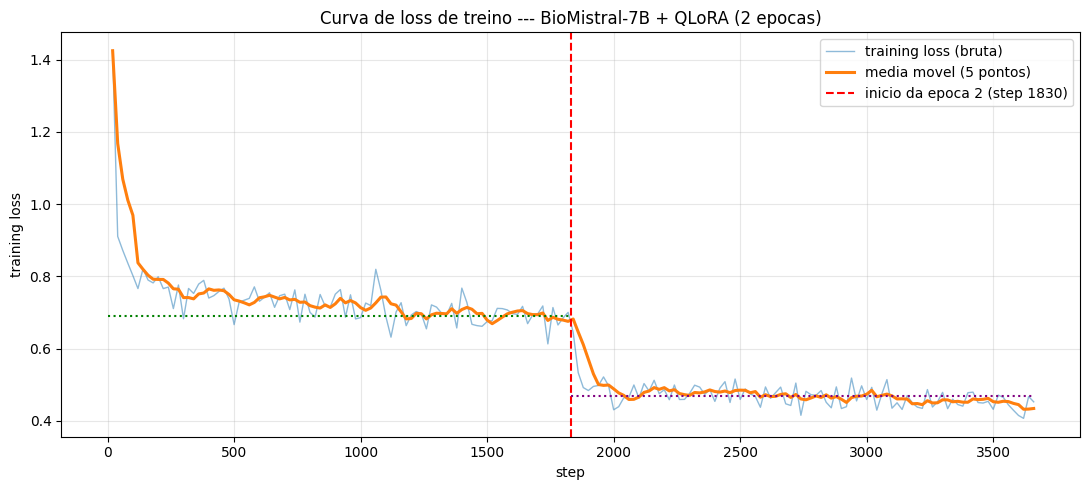

LEITURA DA CURVA
  Loss inicial (step 20)..................: 1.425
  Loss media --- final da epoca 1.........: 0.691
  Loss media --- epoca 2 inteira..........: 0.470
  Degrau no comeco da epoca 2............: 0.221 nats para baixo

  -> Existe um degrau claro quando a epoca 2 comeca.
     O modelo passou a acertar MUITO melhor exemplos que ja tinha visto.
     Isso e o classico 1o sinal de OVERFITTING LEVE na 2a epoca.

  -> Na epoca 2 a loss ESTABILIZOU (~0.45), nao despencou para ~0.
     Ou seja: se ha overfitting, ele e LEVE, nao catastrofico.

  IMPORTANTE: a curva de TREINO sozinha nao fecha a conclusao.
  Falta comparar com dados que o modelo NUNCA viu -> Secoes 11.2 e 13.3.


In [24]:
# ============================================================
# SEÇÃO 11.1: Curva de loss de treino (a partir do log da Seção 8)
# ============================================================
import matplotlib.pyplot as plt

# Log copiado da "Saída da seção 8" (step  <TAB>  training loss)
TRAIN_LOG = """
20 1.425015
40 0.910815
60 0.872208
80 0.836784
100 0.802327
120 0.766477
140 0.820915
160 0.790022
180 0.782128
200 0.799095
220 0.766360
240 0.770605
260 0.710993
280 0.776335
300 0.682909
320 0.766794
340 0.752965
360 0.778859
380 0.789178
400 0.740196
420 0.746872
440 0.758348
460 0.767517
480 0.737387
500 0.666623
520 0.729053
540 0.734138
560 0.739303
580 0.771169
600 0.731314
620 0.742491
640 0.754853
660 0.714523
680 0.746575
700 0.750978
720 0.708208
740 0.762832
760 0.673548
780 0.750803
800 0.700468
820 0.687337
840 0.750080
860 0.717627
880 0.715287
900 0.750960
920 0.763742
940 0.687063
960 0.749196
980 0.682367
1000 0.686075
1020 0.726342
1040 0.719475
1060 0.819817
1080 0.761964
1100 0.688301
1120 0.631912
1140 0.701239
1160 0.727347
1180 0.663750
1200 0.693236
1220 0.702968
1240 0.696678
1260 0.654970
1280 0.721226
1300 0.715152
1320 0.698309
1340 0.693118
1360 0.725488
1380 0.657390
1400 0.767714
1420 0.727760
1440 0.667467
1460 0.663843
1480 0.661992
1500 0.674924
1520 0.677854
1540 0.711606
1560 0.711000
1580 0.707258
1600 0.697049
1620 0.694921
1640 0.717181
1660 0.669319
1680 0.693333
1700 0.696291
1720 0.718297
1740 0.613263
1760 0.713931
1780 0.665552
1800 0.685021
1820 0.700543
1840 0.645472
1860 0.533460
1880 0.492297
1900 0.484157
1920 0.495517
1940 0.498136
1960 0.521814
1980 0.497355
2000 0.430841
2020 0.439425
2040 0.464061
2060 0.465067
2080 0.499513
2100 0.463024
2120 0.503436
2140 0.482862
2160 0.512533
2180 0.475393
2200 0.486357
2220 0.458672
2240 0.499444
2260 0.459282
2280 0.459584
2300 0.476216
2320 0.498962
2340 0.493584
2360 0.473498
2380 0.486715
2400 0.454081
2420 0.490848
2440 0.508711
2460 0.451088
2480 0.515961
2500 0.459500
2520 0.488421
2540 0.474952
2560 0.467527
2580 0.437772
2600 0.494091
2620 0.462760
2640 0.478247
2660 0.493617
2680 0.447338
2700 0.442742
2720 0.504775
2740 0.415566
2760 0.482033
2780 0.472554
2800 0.471077
2820 0.483994
2840 0.451529
2860 0.436261
2880 0.494207
2900 0.434225
2920 0.439365
2940 0.518660
2960 0.455412
2980 0.497127
3000 0.459296
3020 0.492876
3040 0.429821
3060 0.474764
3080 0.514395
3100 0.435159
3120 0.450216
3140 0.431767
3160 0.470215
3180 0.450187
3200 0.438217
3220 0.434687
3240 0.486812
3260 0.438461
3280 0.452950
3300 0.479031
3320 0.433947
3340 0.460248
3360 0.445312
3380 0.440931
3400 0.478121
3420 0.479655
3440 0.450820
3460 0.449467
3480 0.454273
3500 0.432071
3520 0.471308
3540 0.465208
3560 0.444569
3580 0.429519
3600 0.415150
3620 0.407133
3640 0.467596
3660 0.452822
"""

pares  = [ln.split() for ln in TRAIN_LOG.strip().splitlines() if ln.strip()]
steps  = [int(p[0])   for p in pares]
losses = [float(p[1]) for p in pares]

# fronteira entre época 1 e época 2 (metade do total de steps)
total_steps   = max(steps)
step_por_epoca = round(total_steps / 2)

ep1 = [l for s, l in zip(steps, losses) if s <= step_por_epoca]
ep2 = [l for s, l in zip(steps, losses) if s >  step_por_epoca]
media_ep1 = sum(ep1) / len(ep1)
media_ep2 = sum(ep2) / len(ep2)
# media so da PARTE FINAL da epoca 1 (ultimos ~25%), para comparar "regime estavel"
cauda_ep1 = ep1[int(len(ep1) * 0.75):]
media_cauda_ep1 = sum(cauda_ep1) / len(cauda_ep1)

plt.figure(figsize=(11, 5))
plt.plot(steps, losses, lw=1, alpha=0.5, label="training loss (bruta)")
# media movel para enxergar a tendencia
w = 5
mm = [sum(losses[max(0, i - w + 1): i + 1]) / len(losses[max(0, i - w + 1): i + 1])
      for i in range(len(losses))]
plt.plot(steps, mm, lw=2.2, label=f"media movel ({w} pontos)")
plt.axvline(step_por_epoca, color="red", ls="--", lw=1.5,
            label=f"inicio da epoca 2 (step {step_por_epoca})")
plt.hlines(media_cauda_ep1, 0, step_por_epoca, color="green", ls=":", lw=1.5)
plt.hlines(media_ep2, step_por_epoca, total_steps, color="purple", ls=":", lw=1.5)
plt.title("Curva de loss de treino --- BioMistral-7B + QLoRA (2 epocas)")
plt.xlabel("step"); plt.ylabel("training loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

degrau = media_cauda_ep1 - media_ep2
print("=" * 64)
print("LEITURA DA CURVA")
print("=" * 64)
print(f"  Loss inicial (step 20)..................: {losses[0]:.3f}")
print(f"  Loss media --- final da epoca 1.........: {media_cauda_ep1:.3f}")
print(f"  Loss media --- epoca 2 inteira..........: {media_ep2:.3f}")
print(f"  Degrau no comeco da epoca 2............: {degrau:.3f} nats para baixo")
print()
if degrau > 0.12:
    print("  -> Existe um degrau claro quando a epoca 2 comeca.")
    print("     O modelo passou a acertar MUITO melhor exemplos que ja tinha visto.")
    print("     Isso e o classico 1o sinal de OVERFITTING LEVE na 2a epoca.")
elif degrau > 0.05:
    print("  -> Ha um degrau pequeno no inicio da epoca 2 (overfitting incipiente).")
else:
    print("  -> Sem degrau relevante entre as epocas (bom sinal).")
print()
if media_ep2 > 0.35 and (min(mm[-10:]) > 0.30):
    print("  -> Na epoca 2 a loss ESTABILIZOU (~0.45), nao despencou para ~0.")
    print("     Ou seja: se ha overfitting, ele e LEVE, nao catastrofico.")
print()
print("  IMPORTANTE: a curva de TREINO sozinha nao fecha a conclusao.")
print("  Falta comparar com dados que o modelo NUNCA viu -> Secoes 11.2 e 13.3.")


---

# SEÇÃO 11.2 --- Perplexity do FINE-TUNED, feita direito (val inteiro + máscara)

A Seção 11 já mediu perplexity, mas de um jeito que **subestima** o erro:

| Problema da Seção 11 | Correção aqui |
|---|---|
| Usou só **100** das 816 amostras de validação | Usa as **816** |
| Contou o erro no **texto inteiro** (pergunta + resposta). Prever a pergunta é fácil, pois ela está no prompt --- isso puxa o número para baixo | **Mascara o prompt** (`labels = -100`): o modelo só é avaliado pela **resposta**, que é o que ele de fato teve que gerar |

Também medimos a perplexity **no próprio train set** (300 amostras). O par
`(treino, validação)` é o que revela overfitting:

- perplexity de treino **muito menor** que a de validação  ->  o modelo decora o treino
  e generaliza mal  ->  **overfitting**.
- as duas **parecidas**  ->  **sem overfitting**.

Os resultados são salvos em `ppl_finetuned.json` para a comparação final (Seção 13.3).

> Lembrete: `perplexity = exp(loss)`. É "entre quantas palavras o modelo fica na
> dúvida, em média". Menor = melhor.


In [33]:
try:
    model
    print("model ja carregado")
except NameError:
    from unsloth import FastLanguageModel
    MODEL_DIR = "/content/drive/MyDrive/techchallenge_fase3/biomistral-medquad-lora"
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_DIR, max_seq_length=4096, dtype=None, load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    print("modelo fine-tuned recarregado")


==((====))==  Unsloth 2026.8.22: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 77, in get_conversion_pr_reference
    raise OSError(
    ...<2 lines>...
    )
OSError: Could not create safetensors conversion PR. The repo does not appear t

modelo fine-tuned recarregado


In [34]:
# ============================================================
# SEÇÃO 11.2: Perplexity mascarada do modelo FINE-TUNED
#             (val inteiro + amostra de treino)  ->  salva em JSON
# ============================================================
import math, json, torch
from datasets import load_dataset

RESP_TAG = "### Response:\n"   # tudo ANTES disto e' prompt -> nao conta na loss

def perplexity_mascarada(mdl, tok, dataset, max_samples=None, max_len=4096, tag="set"):
    """Perplexity contando SO os tokens da resposta (prompt vira label -100)."""
    mdl.eval()
    soma_loss, soma_tok, usadas = 0.0, 0, 0
    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    with torch.no_grad():
        for i in range(n):
            ex = dataset[i]
            full   = alpaca_prompt.format(ex["instruction"], ex.get("input", ""), ex["output"])
            prefixo = full.split(RESP_TAG)[0] + RESP_TAG
            enc = tok(full, return_tensors="pt", truncation=True, max_length=max_len).to("cuda")
            len_prefixo = tok(prefixo, return_tensors="pt", truncation=True,
                              max_length=max_len)["input_ids"].shape[1]
            labels = enc["input_ids"].clone()
            labels[0, :len_prefixo] = -100          # ignora o prompt
            n_resp = int((labels != -100).sum().item())
            if n_resp == 0:                          # resposta foi toda truncada
                continue
            out = mdl(**enc, labels=labels)
            soma_loss += out.loss.item() * n_resp   # loss e' media/token -> re-soma
            soma_tok  += n_resp
            usadas    += 1
            if usadas % 100 == 0:
                print(f"   [{tag}] {usadas}/{n} amostras...")
    loss = soma_loss / soma_tok
    return {"loss": loss, "perplexity": math.exp(loss),
            "tokens_resposta": soma_tok, "amostras": usadas}

val_ds   = load_dataset("json", data_files=f"{DATA_DIR}/val.jsonl",   split="train")
train_ds = load_dataset("json", data_files=f"{DATA_DIR}/train.jsonl", split="train")

print("Medindo FINE-TUNED no VAL (816 amostras)...")
ft_val   = perplexity_mascarada(model, tokenizer, val_ds,   max_samples=None, tag="val")
print("\nMedindo FINE-TUNED no TREINO (300 amostras)...")
ft_train = perplexity_mascarada(model, tokenizer, train_ds, max_samples=300,  tag="treino")

resultado = {"finetuned_val": ft_val, "finetuned_train": ft_train}
with open(f"{WORKDIR}/ppl_finetuned.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)

print("\n" + "=" * 64)
print("PERPLEXITY MASCARADA --- MODELO FINE-TUNED")
print("=" * 64)
print(f"  Treino (300):  loss {ft_train['loss']:.4f}  |  perplexity {ft_train['perplexity']:.2f}")
print(f"  Validacao(816): loss {ft_val['loss']:.4f}  |  perplexity {ft_val['perplexity']:.2f}")
gap = ft_val["perplexity"] / ft_train["perplexity"]
print(f"  Razao val/treino: {gap:.2f}x", end="   ")
print("(1.0-1.8 = ok | 1.8-3 = overfitting leve | >3 = overfitting moderado/alto)")
print("\n  Salvo em ppl_finetuned.json --- usado na Secao 13.3.")


Medindo FINE-TUNED no VAL (816 amostras)...
   [val] 100/816 amostras...
   [val] 200/816 amostras...
   [val] 300/816 amostras...
   [val] 400/816 amostras...
   [val] 500/816 amostras...
   [val] 600/816 amostras...
   [val] 700/816 amostras...
   [val] 800/816 amostras...

Medindo FINE-TUNED no TREINO (300 amostras)...
   [treino] 100/300 amostras...
   [treino] 200/300 amostras...
   [treino] 300/300 amostras...

PERPLEXITY MASCARADA --- MODELO FINE-TUNED
  Treino (300):  loss 0.3926  |  perplexity 1.48
  Validacao(816): loss 0.7780  |  perplexity 2.18
  Razao val/treino: 1.47x   (1.0-1.8 = ok | 1.8-3 = overfitting leve | >3 = overfitting moderado/alto)

  Salvo em ppl_finetuned.json --- usado na Secao 13.3.


---

# SEÇÃO 12: Avaliação qualitativa — gerar respostas para revisão

In [35]:
# ============================================================
# SEÇÃO 12: Avaliação qualitativa — comparar com gabarito
# ============================================================
import json
import os

TEST_FILE = f"{DATA_DIR}/test.jsonl"
EVAL_OUTPUT = f"{WORKDIR}/eval_results_qualitativo.json"

if not os.path.exists(TEST_FILE):
    print(f"⚠️  test.jsonl não encontrado. Pulando esta seção.")
else:
    test_dataset = load_dataset("json", data_files=TEST_FILE, split="train")

    # Pegar 20 amostras aleatórias
    import random
    rng = random.Random(42)
    indices = rng.sample(range(len(test_dataset)), min(20, len(test_dataset)))
    samples = [test_dataset[i] for i in indices]

    results = []
    print(f"🚀 Gerando respostas para {len(samples)} perguntas...\n")

    for i, example in enumerate(samples):
        input_text = alpaca_prompt.format(
            example["instruction"],
            example.get("input", ""),
            ""
        )
        inputs = tokenizer([input_text], return_tensors="pt").to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.2,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response.split("### Response:")[-1].strip()

        results.append({
            "instruction": example["instruction"],
            "expected": example["output"][:500],
            "generated": response[:500],
        })

        print(f"  [{i+1}/20] {example['instruction'][:60]}... OK")

    # Salvar
    with open(EVAL_OUTPUT, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Resultados salvos em: {EVAL_OUTPUT}")
    print(f"   {len(results)} pares (esperado vs gerado) para revisão manual")

    # Mostrar 2 exemplos lado a lado
    print("\n" + "=" * 70)
    print("📋 EXEMPLOS LADO A LADO")
    print("=" * 70)
    for r in results[:2]:
        print(f"\n--- PERGUNTA ---")
        print(f"   {r['instruction']}")
        print(f"\n--- ESPERADO ---")
        print(f"   {r['expected'][:300]}...")
        print(f"\n--- GERADO ---")
        print(f"   {r['generated'][:300]}...")
        print()

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🚀 Gerando respostas para 20 perguntas...



Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [1/20] What is (are) Platelet Disorders ?... OK


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [17/20] What is (are) Kidney Cysts ?... OK


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [18/20] How many people are affected by Stickler syndrome ?... OK


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [19/20] What is (are) Leukodystrophies ?... OK
  [20/20] What are the symptoms of Familial juvenile hyperuricaemic ne... OK

✅ Resultados salvos em: /content/drive/MyDrive/techchallenge_fase3/eval_results_qualitativo.json
   20 pares (esperado vs gerado) para revisão manual

📋 EXEMPLOS LADO A LADO

--- PERGUNTA ---
   What is (are) Platelet Disorders ?

--- ESPERADO ---
   Platelets are little pieces of blood cells. Platelets help wounds heal and prevent bleeding by forming blood clots. Your bone marrow makes platelets. Problems can result from having too few or too many platelets, or from platelets that do not work properly. If your blood has a low number of platelet...

--- GERADO ---
   Platelets are blood cell fragments that form in your bone marrow. They're called thrombocytes because they help your blood to clot. A healthy person usually has 150,000 to 450,000 platelets per cubic centimeter of blood. When you cut or scratch yourself, bleeding occurs. The process of forming bloo

#SEÇÃO 13 - OUTROS TESTES

In [36]:
# ============================================================
# SEÇÃO 13.1: Teste de generalização (15 perguntas)
# ============================================================
from unsloth import FastLanguageModel
import torch

# Re-ativar modo inferência
FastLanguageModel.for_inference(model)

def perguntar(instruction: str, topic: str = ""):
    """Faz uma pergunta ao modelo fine-tuned."""
    input_text = alpaca_prompt.format(
        instruction,
        f"Context / Topic: {topic}" if topic else "",
        ""
    )
    inputs = tokenizer([input_text], return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.5,        # mais determinístico p/ teste
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.3,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response.split("### Response:")[-1].strip()

# 15 perguntas de teste (3 categorias)
TESTES = [
    # === CATEGORIA 1: Perguntas FORA do MedQuAD (gerais) ===
    ("What are the early signs of lung cancer?", "Lung Cancer"),
    ("How is multiple sclerosis diagnosed?", "Multiple Sclerosis"),
    ("What lifestyle changes help prevent heart disease?", "Heart Disease Prevention"),
    ("What is the difference between Type 1 and Type 2 diabetes?", "Diabetes Comparison"),
    ("What are the warning signs of a stroke?", "Stroke Symptoms"),

    # === CATEGORIA 2: Doenças modernas (NÃO no MedQuAD) ===
    ("What are the main symptoms of COVID-19?", "COVID-19"),
    ("How does the mRNA vaccine work?", "mRNA Vaccines"),
    ("What is the treatment for dengue hemorrhagic fever?", "Dengue"),
    ("What are the symptoms of monkeypox?", "Monkeypox"),
    ("How is Zika virus transmitted?", "Zika Virus"),

    # === CATEGORIA 3: Edge cases (robustez) ===
    ("o que é diabetes?", ""),  # português!
    ("tell me about aspirin", ""),  # sem tópico estruturado
    ("asdfghjkl", ""),  # gibberish
    ("What is the meaning of life?", ""),  # fora do escopo médico
    ("", ""),  # pergunta vazia
]

print("=" * 70)
print("🧪 TESTE DE GENERALIZAÇÃO - 15 PERGUNTAS")
print("=" * 70)
print()

resultados = []
for i, (q, topic) in enumerate(TESTES, 1):
    print(f"\n{'─' * 70}")
    print(f"[{i:2d}/15] Categoria: {'GERAL' if i <= 5 else 'MODERNA' if i <= 10 else 'EDGE'}")
    print(f"❓ {q}")
    print(f"📋 Tópico: {topic or '(vazio)'}")
    print(f"🤖 Resposta:")

    try:
        resp = perguntar(q, topic)
        # Mostrar primeiros 400 chars
        print(f"   {resp[:400]}{'...' if len(resp) > 400 else ''}")
        resultados.append({"q": q, "topic": topic, "resp": resp, "len": len(resp)})
    except Exception as e:
        print(f"   ❌ ERRO: {e}")
        resultados.append({"q": q, "topic": topic, "resp": f"ERRO: {e}", "len": 0})

print("\n" + "=" * 70)
print("📊 ANÁLISE AUTOMÁTICA")
print("=" * 70)

# Análise simples
vazias = sum(1 for r in resultados if r["len"] < 20)
repeticoes = sum(1 for r in resultados if r["q"].lower() in r["resp"].lower()[:200])
longas = sum(1 for r in resultados if r["len"] > 100)
print(f"\nTotal: 15 perguntas")
print(f"✅ Respostas longas (>100 chars): {longas}/15")
print(f"⚠️  Respostas vazias/curtas: {vazias}/15")
print(f"🔁 Repetindo a pergunta: {repeticoes}/15")

print("\n🎯 VEREDITO:")
if vazias > 5:
    print("   ❌ OVERFITTING SEVERO - modelo não sabe responder fora do treino")
elif repeticoes > 3:
    print("   ⚠️  OVERFITTING MODERADO - modelo repete padrões do treino")
elif longas >= 12:
    print("   ✅ GENERALIZOU BEM - responde com confiança em dados novos")
else:
    print("   ⚠️  RESULTADO MISTO - analisar manualmente abaixo")

print("\n" + "=" * 70)
print("💾 SALVANDO RESULTADOS")
print("=" * 70)
import json
EVAL_FILE = f"{WORKDIR}/test_generalizacao.json"
with open(EVAL_FILE, "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print(f"✅ Salvos em: {EVAL_FILE}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🧪 TESTE DE GENERALIZAÇÃO - 15 PERGUNTAS


──────────────────────────────────────────────────────────────────────
[ 1/15] Categoria: GERAL
❓ What are the early signs of lung cancer?
📋 Tópico: Lung Cancer
🤖 Resposta:


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Early Signs and Symptoms The most common sign of both small cell lung cancer (SCLC) and non-small cell lung cancer (NSCLC), which account for about 90 percent of all types of lung cancer, is coughing up blood or mucus sputum. Other symptoms may include chest pain; shortness of breath or rapid breathing; wheezing; hoarseness; repeated problems with pneumonia or bronchitis; swelling in the face, nec...

──────────────────────────────────────────────────────────────────────
[ 2/15] Categoria: GERAL
❓ How is multiple sclerosis diagnosed?
📋 Tópico: Multiple Sclerosis
🤖 Resposta:


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

   Aspirin (acetylsalicylic acid) has been used for many years as a pain reliever and to reduce fever in people who have inflammation or swelling. It also slows down blood clotting by reducing platelet production. Aspirin can be taken daily without serious side effects except when it's combined with other medicines such as antidepressants, nonsteroidal anti-inflammatory drugs, steroids, and certain a...

──────────────────────────────────────────────────────────────────────
[13/15] Categoria: EDGE
❓ asdfghjkl
📋 Tópico: (vazio)
🤖 Resposta:


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   What are the treatments for Paroxysmal Choreoathetosis ? Treatment of paroxysmal choreoathetosis may include anticholinergic drugs such as trihexyphenidyl or benztropine; dopamimimetics including levodopa and dopamine-like neurotransmitters (such as pramipexole); and/or anti-seizure medications such as clonazepam.

──────────────────────────────────────────────────────────────────────
[14/15] Categoria: EDGE
❓ What is the meaning of life?
📋 Tópico: (vazio)
🤖 Resposta:


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   The question "what is the meaning of life?" has been asked by many philosophers and thinkers throughout history. It remains one of philosophy's most difficult questions to answer. Different people have different answers for this question because everyone may not share the same beliefs or values about what constitutes meaningfulness in our lives (e.g., some might find having children as being valua...

──────────────────────────────────────────────────────────────────────
[15/15] Categoria: EDGE
❓ 
📋 Tópico: (vazio)
🤖 Resposta:
   What are the treatments for Paget disease of bone ?

These resources address the diagnosis or management of Paget disease of bone: - Genetic Testing Registry: Osteitis deformans These resources from MedlinePlus offer information about the diagnosis and management of various health conditions: - Diagnostic Tests - Drug Therapy - Surgery and Rehabilitation - Genetic Counseling - Palliative Care

📊 ANÁLISE AUTOMÁTICA

Total: 15 perguntas
✅ Respostas longas (>1

In [37]:
# ============================================================
# SEÇÃO 13.2: Comparação modelo FINE-TUNED vs BASE
# ============================================================
import gc
from unsloth import FastLanguageModel
import torch

print("=" * 70)
print("🔬 COMPARAÇÃO: FINE-TUNED vs BASE (mesmas perguntas)")
print("=" * 70)

# Salvar referência ao modelo fine-tuned
print("\n1️⃣ Carregando modelo BASE (BioMistral-7B sem fine-tuning)...")
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="BioMistral/BioMistral-7B",
    max_seq_length=4096,
    dtype=None,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)
print("✅ Modelo base carregado")

def perguntar_base(prompt_template, llm, tok, instruction, topic=""):
    input_text = prompt_template.format(
        instruction,
        f"Context / Topic: {topic}" if topic else "",
        ""
    )
    inputs = tok([input_text], return_tensors="pt").to("cuda")
    outputs = llm.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.5,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.3,
    )
    response = tok.decode(outputs[0], skip_special_tokens=True)
    return response.split("### Response:")[-1].strip()

PERGUNTAS_TESTE = [
    ("What are the early signs of lung cancer?", "Lung Cancer"),
    ("How does the mRNA vaccine work?", "mRNA Vaccines"),
    ("o que é diabetes?", ""),
]

for i, (q, topic) in enumerate(PERGUNTAS_TESTE, 1):
    print(f"\n{'─' * 70}")
    print(f"[{i}] PERGUNTA: {q}")
    if topic:
        print(f"    Tópico: {topic}")

    print(f"\n    🤖 BASE (sem fine-tuning):")
    try:
        resp_base = perguntar_base(alpaca_prompt, base_model, base_tokenizer, q, topic)
        print(f"       {resp_base[:250]}{'...' if len(resp_base) > 250 else ''}")
    except Exception as e:
        print(f"       ❌ ERRO: {e}")

print("\n" + "=" * 70)
print("💡 ANÁLISE MANUAL:")
print("=" * 70)
print("""
Compare as respostas dos 2 modelos:

✅ SEU MODELO melhor que o base SE:
   - Resposta é mais clínica e estruturada
   - Menos alucinações / divagações
   - Tom similar ao MedQuAD (formal, informativo)

🤷 SE FOREM SIMILARES:
   - O fine-tuning não agregou muito (dataset MedQuAD é genérico)
   - Mas ainda é válido pra Tech Challenge (mostra que não degradou)

❌ SE SEU MODELO for PIOR:
   - Houve overfitting sério
   - Considere retreinar com mais regularization
""")

🔬 COMPARAÇÃO: FINE-TUNED vs BASE (mesmas perguntas)

1️⃣ Carregando modelo BASE (BioMistral-7B sem fine-tuning)...
==((====))==  Unsloth 2026.8.22: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
  File "/usr/local/lib/python3.13/dist-packages/transformers/safetensors_conversion.py", line 77, in get_conversion_pr_reference
    raise OSError(
    ...<2 lines>...
    )
OSError: Could not create safetensors conversion PR. The repo does not appear t

Unsloth: BioMistral/BioMistral-7B has no pad_token. Using pad_token = <unk>.


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Modelo base carregado

──────────────────────────────────────────────────────────────────────
[1] PERGUNTA: What are the early signs of lung cancer?
    Tópico: Lung Cancer

    🤖 BASE (sem fine-tuning):


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


       There may be several warning signs for lung cancer and it’s important to note that not all people will experience them especially in their earlier stages. However, some common symptoms include coughing (especially if you’re a non-smoker), persistent ...

──────────────────────────────────────────────────────────────────────
[2] PERGUNTA: How does the mRNA vaccine work?
    Tópico: mRNA Vaccines

    🤖 BASE (sem fine-tuning):


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


       The COVID-19 vaccinations currently available in the United States use messenger RNA (mRNA) to teach your body how to fight against SARS-CoV2 virus infection . The Pfizer and Moderna vaccines are both two doses given 3 weeks apart while Janssen/Johns...

──────────────────────────────────────────────────────────────────────
[3] PERGUNTA: o que é diabetes?

    🤖 BASE (sem fine-tuning):
       O diabetes mellitus (DM) ou simplesmente diabetes é uma doença crônica caracterizada pela presença de hiperglicemia persistentemente elevada na circulação sanguínea decorrente da falta de produção e/ou uso inadequado dos hormonios insulina e glucagon...

💡 ANÁLISE MANUAL:

Compare as respostas dos 2 modelos:

✅ SEU MODELO melhor que o base SE:
   - Resposta é mais clínica e estruturada
   - Menos alucinações / divagações
   - Tom similar ao MedQuAD (formal, informativo)

🤷 SE FOREM SIMILARES:
   - O fine-tuning não agregou muito (dataset MedQuAD é genérico)
   - Mas ainda é válido pra Tech 

---

# SEÇÃO 13.3 --- Peça 3: Baseline (BASE vs FINE-TUNED) + veredito

**A pergunta que só o baseline responde:** o fine-tuning **melhorou**, **empatou** ou
**piorou** o modelo?

A perplexity do fine-tuned (7.19 na Seção 11, ou o valor da Seção 11.2) só significa
alguma coisa quando comparada com o **mesmo modelo, antes do treino**, medido do
**mesmo jeito** e no **mesmo conjunto**. Talvez o BioMistral já respondesse igual sem
nenhum ajuste --- ou talvez fosse muito pior.

Esta célula **reaproveita o `base_model`** que a Seção 13.2 já carregou, roda a **mesma**
`perplexity_mascarada` no **mesmo** val set e junta tudo num veredito:

| Comparação | Como ler |
|---|---|
| `ppl_base` bem **maior** que `ppl_ft` | ✅ o fine-tuning ajudou de verdade |
| `ppl_base` ≈ `ppl_ft` | 🤷 o fine-tuning quase não mudou nada |
| `ppl_base` **menor** que `ppl_ft` | ❌ o fine-tuning **piorou** --- overfitting sério |

> ⚠️ Rode esta célula **depois** da Seção 13.2 (é ela que carrega `base_model`).


In [38]:
# ============================================================
# SEÇÃO 13.3: Perplexity do modelo BASE + veredito de overfitting
#             (usa base_model / base_tokenizer da Secao 13.2)
# ============================================================
import json
from datasets import load_dataset

assert "base_model" in dir(), "Rode a SECAO 13.2 antes (ela carrega o base_model)."
assert "perplexity_mascarada" in dir(), "Rode a SECAO 11.2 antes (ela define a funcao)."

val_ds = load_dataset("json", data_files=f"{DATA_DIR}/val.jsonl", split="train")

print("Medindo BASE (BioMistral-7B sem adapter) no VAL (816 amostras)...")
base_val = perplexity_mascarada(base_model, base_tokenizer, val_ds, max_samples=None, tag="base-val")

ft = json.load(open(f"{WORKDIR}/ppl_finetuned.json", encoding="utf-8"))
ft_val, ft_train = ft["finetuned_val"], ft["finetuned_train"]

melhora  = base_val["perplexity"] / ft_val["perplexity"]        # >1 => fine-tune ajudou
gap      = ft_val["perplexity"]   / ft_train["perplexity"]       # >>1 => decorou o treino

print("\n" + "=" * 68)
print("COMPARACAO FINAL --- perplexity mascarada, mesmo val set (816)")
print("=" * 68)
print(f"  BASE        (val) : perplexity {base_val['perplexity']:6.2f}  | loss {base_val['loss']:.4f}")
print(f"  FINE-TUNED  (val) : perplexity {ft_val['perplexity']:6.2f}  | loss {ft_val['loss']:.4f}")
print(f"  FINE-TUNED (treino): perplexity {ft_train['perplexity']:6.2f}  | loss {ft_train['loss']:.4f}")
print("-" * 68)
print(f"  Ganho do fine-tuning (base/ft no val) : {melhora:.2f}x")
print(f"  Gap treino->val do fine-tuned         : {gap:.2f}x")
print("=" * 68)

print("\nVEREDITO AUTOMATICO SOBRE OVERFITTING:")
if melhora < 1.0:
    print("  [X] OVERFITTING PREJUDICIAL")
    print("      O modelo ajustado ficou PIOR que o base em dados nao vistos.")
    print("      Acao: treinar menos (1 epoca), reduzir LR, ou mais dados.")
elif gap >= 3.0:
    print("  [!] OVERFITTING MODERADO")
    print("      Acerta o treino MUITO melhor do que dados novos.")
    print("      Acao: 1 epoca + early stopping (Secao 14).")
elif gap >= 1.8:
    print("  [~] OVERFITTING LEVE (dentro do esperado para fine-tuning)")
    print("      Ha alguma memorizacao, mas o modelo ainda generaliza.")
    print("      Aceitavel para o Tech Challenge; da pra melhorar com 1 epoca.")
else:
    print("  [OK] SEM OVERFITTING RELEVANTE")
    print("      O erro em treino e em validacao sao parecidos.")

if 1.0 <= melhora < 1.15:
    print("\n  Obs.: o ganho sobre o modelo base foi PEQUENO --- o fine-tuning")
    print("        quase nao mudou a qualidade (o MedQuAD e' bem generico).")
print("\n  Combine este resultado com o degrau da curva (Secao 11.1)")
print("  e com a Secao 14 (loss de validacao DURANTE o treino) para conclusao 100%.")


Medindo BASE (BioMistral-7B sem adapter) no VAL (816 amostras)...
   [base-val] 100/816 amostras...
   [base-val] 200/816 amostras...
   [base-val] 300/816 amostras...
   [base-val] 400/816 amostras...
   [base-val] 500/816 amostras...
   [base-val] 600/816 amostras...
   [base-val] 700/816 amostras...
   [base-val] 800/816 amostras...

COMPARACAO FINAL --- perplexity mascarada, mesmo val set (816)
  BASE        (val) : perplexity   4.31  | loss 1.4620
  FINE-TUNED  (val) : perplexity   2.18  | loss 0.7780
  FINE-TUNED (treino): perplexity   1.48  | loss 0.3926
--------------------------------------------------------------------
  Ganho do fine-tuning (base/ft no val) : 1.98x
  Gap treino->val do fine-tuned         : 1.47x

VEREDITO AUTOMATICO SOBRE OVERFITTING:
  [OK] SEM OVERFITTING RELEVANTE
      O erro em treino e em validacao sao parecidos.

  Combine este resultado com o degrau da curva (Secao 11.1)
  e com a Secao 14 (loss de validacao DURANTE o treino) para conclusao 100%.


---

# SEÇÃO 14 --- Peça 2 (definitiva): loss de validação **durante** o treino

As Seções 11.1 e 13.3 medem tudo **depois** que o treino acabou. Elas dão uma resposta
quase certa, mas não mostram **o momento exato** em que o modelo começa a piorar em
dados novos.

A prova definitiva de overfitting é a **curva dupla**: `training loss` e `eval loss`
(validação) no mesmo gráfico, medidas **ao longo** do treino.

- as duas descem juntas e estabilizam  ->  **sem overfitting**;
- o `training loss` continua caindo mas o `eval loss` **atinge um mínimo e volta a
  subir**  ->  **overfitting**, e o fundo dessa curva é o ponto ideal de parada.

Esta seção re-treina **com instrumentação**:

- `eval_strategy="steps"` + `eval_steps=100`  ->  mede validação a cada 100 passos;
- `load_best_model_at_end=True`  ->  no fim, fica com o **melhor** checkpoint (menor
  `eval_loss`), não com o último;
- `EarlyStoppingCallback`  ->  para sozinho se a validação não melhora mais;
- salva `train_log_history.json` e plota a curva dupla.

### ⚠️ Como rodar (importante)

Esta célula **substitui** as Seções 7 e 8. Para rodar do jeito certo:

1. **Runtime -> Restart runtime** (limpa a memória).
2. Rode as **Seções 1 a 6** normalmente (setup, deps, Drive, modelo, LoRA, dataset).
3. **Pule as Seções 7 e 8** e rode **esta Seção 14**.
4. Depois siga para a Seção 9 em diante.

Tempo em A100: ~1h30-2h (2 épocas). Se quiser só confirmar a tendência, troque para
`num_train_epochs=3` para deixar o overfitting aparecer com folga, ou reduza o
`train_dataset` para um teste rápido.


In [ ]:
# ============================================================
# SEÇAO 14: RE-TREINO INSTRUMENTADO (train loss + eval loss juntos)
#   - rode depois das Secoes 1..6, no lugar das Secoes 7 e 8
# ============================================================
import json
import matplotlib.pyplot as plt
from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback

# ---- conjunto de validacao formatado igual ao de treino --------------------
from datasets import load_dataset
val_raw = load_dataset("json", data_files=f"{DATA_DIR}/val.jsonl", split="train")
val_fmt = val_raw.map(format_example)                       # usa a funcao da Secao 6.1
val_fmt = val_fmt.select(range(min(300, len(val_fmt))))     # 300 e' suficiente e rapido

CKPT_DIR_INSTR = f"{WORKDIR}/checkpoints_instrumentado"

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,          # 'dataset' ja formatado na Secao 6.1
    eval_dataset=val_fmt,           # <<< a peca que faltava
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=50,
        num_train_epochs=2,                 # experimente 3 p/ ver o overfit com folga
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=20,
        eval_strategy="steps",              # <<< avalia a validacao...
        eval_steps=100,                     # <<< ...a cada 100 steps
        save_strategy="steps",              # precisa casar com eval p/ load_best_model
        save_steps=100,
        save_total_limit=3,
        load_best_model_at_end=True,        # <<< fica com o melhor, nao com o ultimo
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=42,
        output_dir=CKPT_DIR_INSTR,
        report_to="none",
    ),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],  # para se nao melhora 4x seguidas
)

print("Iniciando re-treino instrumentado (train loss + eval loss)...")
trainer.train()

# ---- salvar o historico ---------------------------------------------------
hist = trainer.state.log_history
with open(f"{WORKDIR}/train_log_history.json", "w", encoding="utf-8") as f:
    json.dump(hist, f, ensure_ascii=False, indent=2)

tr = [(h["step"], h["loss"])      for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(11, 5))
if tr: plt.plot(*zip(*tr), lw=1.6, label="training loss")
if ev: plt.plot(*zip(*ev), lw=2.2, marker="o", label="eval loss (validacao)")
if ev:
    s_best, l_best = min(ev, key=lambda x: x[1])
    plt.axvline(s_best, color="green", ls="--", label=f"melhor eval_loss (step {s_best})")
plt.title("Curva dupla --- treino vs validacao (prova de overfitting)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{WORKDIR}/curva_dupla.png", dpi=120); plt.show()

print("\n" + "=" * 64)
print("COMO LER:")
print("=" * 64)
if ev:
    primeiro_ev = ev[0][1]; ultimo_ev = ev[-1][1]; melhor_ev = min(e[1] for e in ev)
    print(f"  eval_loss inicial : {primeiro_ev:.4f}")
    print(f"  eval_loss final   : {ultimo_ev:.4f}")
    print(f"  melhor eval_loss  : {melhor_ev:.4f} (step {s_best})")
    if ultimo_ev > melhor_ev + 0.03:
        print("  -> O eval_loss SUBIU depois do minimo => OVERFITTING confirmado.")
        print(f"     Ponto ideal de parada: step {s_best} (o load_best_model_at_end ja usou esse).")
    else:
        print("  -> O eval_loss NAO subiu de forma relevante => SEM overfitting.")
print("\n  Historico salvo em train_log_history.json e grafico em curva_dupla.png")


---

# 🎉 CONCLUSÃO

Parabéns! Você completou o **fine-tuning do BioMistral-7B** com o dataset MedQuAD.

## 📁 O que você tem agora

1. **Modelo fine-tuned**: `biomistral-medquad-lora/` (~80MB) — pronto pra usar no pipeline LangChain
2. **Resultados qualitativos**: `eval_results_qualitativo.json` — 20 pares pra revisar
3. **Checkpoints**: `checkpoints/` — versões intermediárias
4. **Relatórios do treino**: loss/perplexity impressos

## 🚀 Próximos passos

1. **Baixar modelo pro seu PC**:
   - Pasta `biomistral-medquad-lora/` no Drive
   - Copiar pra `C:\\Users\\Teste\\Downloads\\Techchalleng3\\biomistral-medquad-lora\\`
   - Rodar `python src/ui/gradio_app.py` — vai detectar e usar modelo real!

2. **Testar a UI Gradio** (localmente) com modelo real

3. **Deploy em HuggingFace Spaces** (opcional, URL pública)

4. **Gravar vídeo demo** (≤15min) pro Tech Challenge

## 📚 Documentação

- **DOCX do projeto**: `TECHCHALLENGE_FASE3_PROJETO_COMPLETO.docx` no repo
- **Manual UI**: `MANUAL_UI.md` no repo
- **Relatório técnico**: `RELATORIO_TECNICO_PARA_EQUIPE.md` no repo